In [98]:
!pip install librosa matplotlib numpy soundfile noisereduce tqdm pydub transformers torch openai-whisper JiWER
!pip install pyannote.audio==3.1.1 # Install specific version to avoid potential breaking changes
!pip install einops # Dodatkowa zależność dla pyannote.audio

import librosa
import matplotlib.pyplot as plt
import numpy as np
import os
import soundfile as sf
import noisereduce as nr
from tqdm import tqdm
from pydub import AudioSegment 
import torch
from transformers import pipeline
from jiwer import wer

# Potrzebne dla pyannote.audio
from pyannote.audio import Pipeline
from pyannote.core import Segment # Do pracy z segmentami czasu

print("Gotowe!")

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Gotowe!


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [99]:
# Pełna ścieżka do Twojego pliku .WAV
audio_file_path = r"C:\Users\G\Documents\AlchemistOne\lowquality\output_audio.wav" 

# --- Dodatkowa ścieżka do oryginalnego pliku WAV ---
original_wav_file_path = r"C:\Users\G\Documents\AlchemistOne\lowquality\output_audio.wav" # <<< Upewniam się, że jest zdefiniowane tutaj

# --- GLOBALNE PARAMETRY PRZETWARZANIA (Zdefiniowane raz, dostępne wszędzie) ---
TARGET_SR = 16000 # Docelowe próbkowanie

# Parametry wzmocnienia cichych fragmentów
QUIET_THRESHOLD = 0.03
GAIN_FACTOR = 2.0    
FINAL_BOOST_DB = 0   

# Parametry redukcji szumu
NOISE_START_MIN = 11
NOISE_START_SEC = 45
NOISE_START_TIMESTAMP_SECONDS = NOISE_START_MIN * 60 + NOISE_START_SEC
NOISE_PROFILE_DURATION_SEC = 2.0 
PROP_DECREASE = 0.95 

USE_NON_STATIONARY_NOISE_REDUCTION = False 

# Parametry wizualizacji (ile sekund wyświetlać na wykresach)
PLOT_DURATION_SEC = 60.0

print(f"\n=== PARAMETRY KONFIGURACYJNE ===")
print(f"Docelowe próbkowanie: {TARGET_SR} Hz")
print(f"Wzmocnienie: próg={QUIET_THRESHOLD:.2f}, wzmocnienie={GAIN_FACTOR:.1f}x, boost={FINAL_BOOST_DB}dB")
print(f"Redukcja szumu: profil szumu z ~{NOISE_START_MIN}m {NOISE_START_SEC}s przez {NOISE_PROFILE_DURATION_SEC}s, redukcja o {PROP_DECREASE*100:.0f}% {'(niestacjonarna)' if USE_NON_STATIONARY_NOISE_REDUCTION else ''}")
print(f"Wizualizacja: pierwsze {PLOT_DURATION_SEC:.1f}s")


# --- Diagnoza pliku ---
print(f"\n=== DIAGNOZA PLIKU: {os.path.basename(audio_file_path)} ===")
if not os.path.exists(audio_file_path):
    print(f"❌ Błąd: Plik nie istnieje pod ścieżką: {audio_file_path}")
    audio = None
    sr = None
    total_duration_seconds = None
elif not os.path.isfile(audio_file_path):
    print(f"❌ Błąd: '{audio_file_path}' nie jest plikiem.")
    audio = None
    sr = None
    total_duration_seconds = None
else:
    file_size_mb = os.path.getsize(audio_file_path) / (1024 * 1024)
    print(f"✅ Plik '{os.path.basename(audio_file_path)}' znaleziony. Rozmiar: {file_size_mb:.2f} MB")

    try:
        audio_info = AudioSegment.from_file(audio_file_path)
        total_duration_seconds = len(audio_info) / 1000.0 
        print(f"✅ Długość pliku (dekodowana): {total_duration_seconds:.2f} sekund ({total_duration_seconds / 60:.1f} minut)")
        
        estimated_ram_gb = (total_duration_seconds * TARGET_SR * 4) / (1024*1024*1024) 
        print(f"   Szacowane zużycie RAM do wczytania całego audio: {estimated_ram_gb:.2f} GB.")
        if estimated_ram_gb > 1.5: 
            print("⚠️ Ostrzeżenie: Plik audio jest bardzo długi i prawdopodobnie nadal wymaga przetwarzania w kawałkach.")

    except Exception as e:
        print(f"❌ Błąd przy pobieraniu metadanych pliku '{audio_file_path}': {e}")
        total_duration_seconds = None

    sr = TARGET_SR 

    print(f"\n=== PRÓBA WCZYTANIA CAŁEGO PLIKU DO PAMIĘCI ===")
    try:
        audio, _ = librosa.load(audio_file_path, sr=TARGET_SR)
        print(f"✅ Cały plik załadowany: {len(audio)/sr:.1f}s, {sr}Hz")
        
        print(f"   - Amplituda min: {np.min(audio):.4f}")
        print(f"   - Amplituda max: {np.max(audio):.4f}")
        print(f"   - RMS (średnia kwadratowa): {np.sqrt(np.mean(audio**2)):.4f}")
        
    except MemoryError as e:
        print(f"❌ MemoryError: Nadal nie można załadować CAŁEGO pliku do pamięci. {e}")
        print("   Plik audio jest zbyt duży. Musimy przetwarzać w kawałkach (chunkach).")
        audio = None
    except PermissionError:
        print(f"❌ Błąd uprawnień: Nie mogę otworzyć pliku '{audio_file_path}'.")
        print("   Upewnij się, że plik nie jest otwarty w innym programie i masz do niego uprawnienia.")
        audio = None
    except Exception as e:
        print(f"❌ Inny błąd podczas ładowania pliku '{audio_file_path}': {e}")
        print(f"   Szczegóły błędu: {e}")
        audio = None


=== PARAMETRY KONFIGURACYJNE ===
Docelowe próbkowanie: 16000 Hz
Wzmocnienie: próg=0.03, wzmocnienie=2.0x, boost=0dB
Redukcja szumu: profil szumu z ~11m 45s przez 2.0s, redukcja o 95% 
Wizualizacja: pierwsze 60.0s

=== DIAGNOZA PLIKU: output_audio.wav ===
✅ Plik 'output_audio.wav' znaleziony. Rozmiar: 112.47 MB
✅ Długość pliku (dekodowana): 3685.42 sekund (61.4 minut)
   Szacowane zużycie RAM do wczytania całego audio: 0.22 GB.

=== PRÓBA WCZYTANIA CAŁEGO PLIKU DO PAMIĘCI ===
✅ Cały plik załadowany: 3685.4s, 16000Hz
   - Amplituda min: -0.0264
   - Amplituda max: 0.0388
   - RMS (średnia kwadratowa): 0.0012


In [100]:
if 'audio' not in locals() or audio is None and total_duration_seconds is not None:
    print("\nKrok 3: Definicja funkcji przetwarzającej chunk. (Plik jest za duży do wczytania w całości)")

    global_noise_sample = None
    try:
        noise_end_timestamp_seconds_local = NOISE_START_TIMESTAMP_SECONDS + NOISE_PROFILE_DURATION_SEC
        if noise_end_timestamp_seconds_local > total_duration_seconds:
            print(f"❌ Ostrzeżenie: Żądany zakres próbki szumu ({NOISE_START_MIN}m {NOISE_START_SEC}s do {NOISE_PROFILE_DURATION_SEC}s dalej) wykracza poza długość pliku ({total_duration_seconds:.1f}s).")
            print("Pobieram próbkę szumu od końca pliku lub krótszą.")
            noise_end_timestamp_seconds_local = total_duration_seconds
            noise_start_timestamp_seconds_local = max(0, total_duration_seconds - NOISE_PROFILE_DURATION_SEC)
            
        else:
            noise_start_timestamp_seconds_local = NOISE_START_TIMESTAMP_SECONDS
            
        global_noise_sample, _ = librosa.load(audio_file_path, sr=TARGET_SR, 
                                              offset=noise_start_timestamp_seconds_local,
                                              duration=NOISE_PROFILE_DURATION_SEC)
        print(f"✅ Globalna próbka szumu ({len(global_noise_sample)/TARGET_SR:.1f}s) pobrana z {NOISE_START_MIN}m {NOISE_START_SEC}s.")
    except Exception as e:
        print(f"❌ Błąd przy pobieraniu globalnej próbki szumu: {e}")
        global_noise_sample = None

    if global_noise_sample is None:
        print("Nie udało się pobrać próbki szumu. Dalsze przetwarzanie szumu będzie pominięte.")


    def process_audio_chunk(chunk_audio, sr_param, noise_sample_param):
        processed_chunk = np.copy(chunk_audio)

        # KROK 4: Wzmocnienie cichych fragmentów
        for i in range(len(processed_chunk)):
            if np.abs(processed_chunk[i]) < QUIET_THRESHOLD:
                processed_chunk[i] *= GAIN_FACTOR
        
        # KROK 5: Redukcja szumu (ZAWSZE używamy nr.reduce_noise)
        if PROP_DECREASE > 0 and noise_sample_param is not None and len(noise_sample_param) > 0:
            # Implementacja zaawansowanej redukcji szumu za pomocą multiple passes lub z inną konfiguracją
            # Będziemy używać standardowej reduce_noise, ale z potencjalnie dwoma przebiegami
            
            # Pierwszy przebieg (agresywny dla szumu wiatraków)
            processed_chunk = nr.reduce_noise(y=processed_chunk, sr=sr_param, 
                                            y_noise=noise_sample_param, prop_decrease=PROP_DECREASE)
            
            # Opcjonalnie: Drugi przebieg z mniejszą redukcją, dla subtelniejszego szumu
            # processed_chunk = nr.reduce_noise(y=processed_chunk, sr=sr_param, 
            #                                 y_noise=noise_sample_param, prop_decrease=0.5) # Mniej agresywny

        
        # Normalizacja po wszystkich zmianach
        processed_chunk = librosa.util.normalize(processed_chunk)

        # Dodatkowe ogólne wzmocnienie (final_boost_db)
        if FINAL_BOOST_DB > 0:
            boost_linear_gain = 10**(FINAL_BOOST_DB / 20)
            processed_chunk *= boost_linear_gain
            processed_chunk = librosa.util.normalize(processed_chunk) # Ponowna normalizacja po booscie
        
        return processed_chunk

else:
    if 'audio' in locals() and audio is not None:
        print("\nKrok 3 (Definicja funkcji chunkowania) pominięty, ponieważ cały plik audio został wczytany.")
    else:
        print("\nBrak długości pliku lub problem z wczytywaniem. Krok 3 nie może być wykonany.")



Krok 3 (Definicja funkcji chunkowania) pominięty, ponieważ cały plik audio został wczytany.



=== KROK 4: WIZUALIZACJA I PRZETWARZANIE CAŁEGO PLIKU ===
✅ Globalna próbka szumu (2.0s) pobrana z 11m 45s (z pełnego audio).


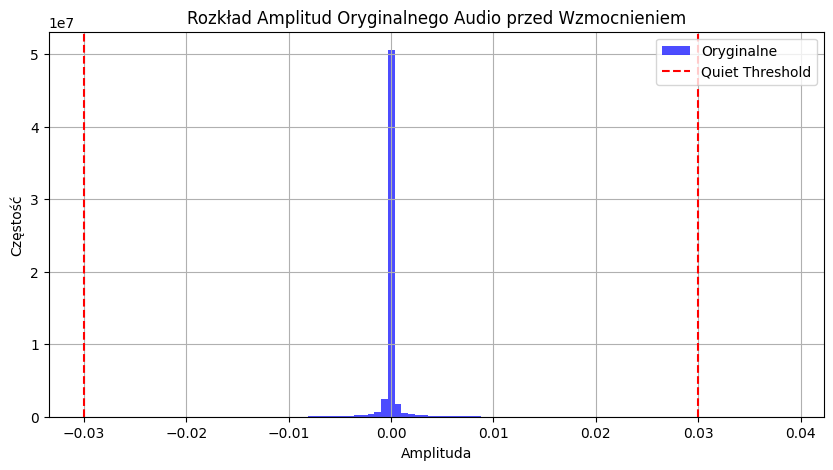

Rozkład amplitud: dźwięki poniżej |0.03| zostaną wzmocnione.


Wzmacnianie cichych fragmentów: 100%|██████████| 58966699/58966699 [00:55<00:00, 1054068.56it/s]


✅ Ciche fragmenty wzmocnione.
Używam zaawansowanej redukcji szumu (może potrwać dłużej)...
✅ Szum tła usunięty.
✅ Normalizacja do piku 1.0.
⚠️ Uwaga: Plik audio jest dłuższy niż 60.0s. Wykresy pokazują tylko pierwsze 60.0s.


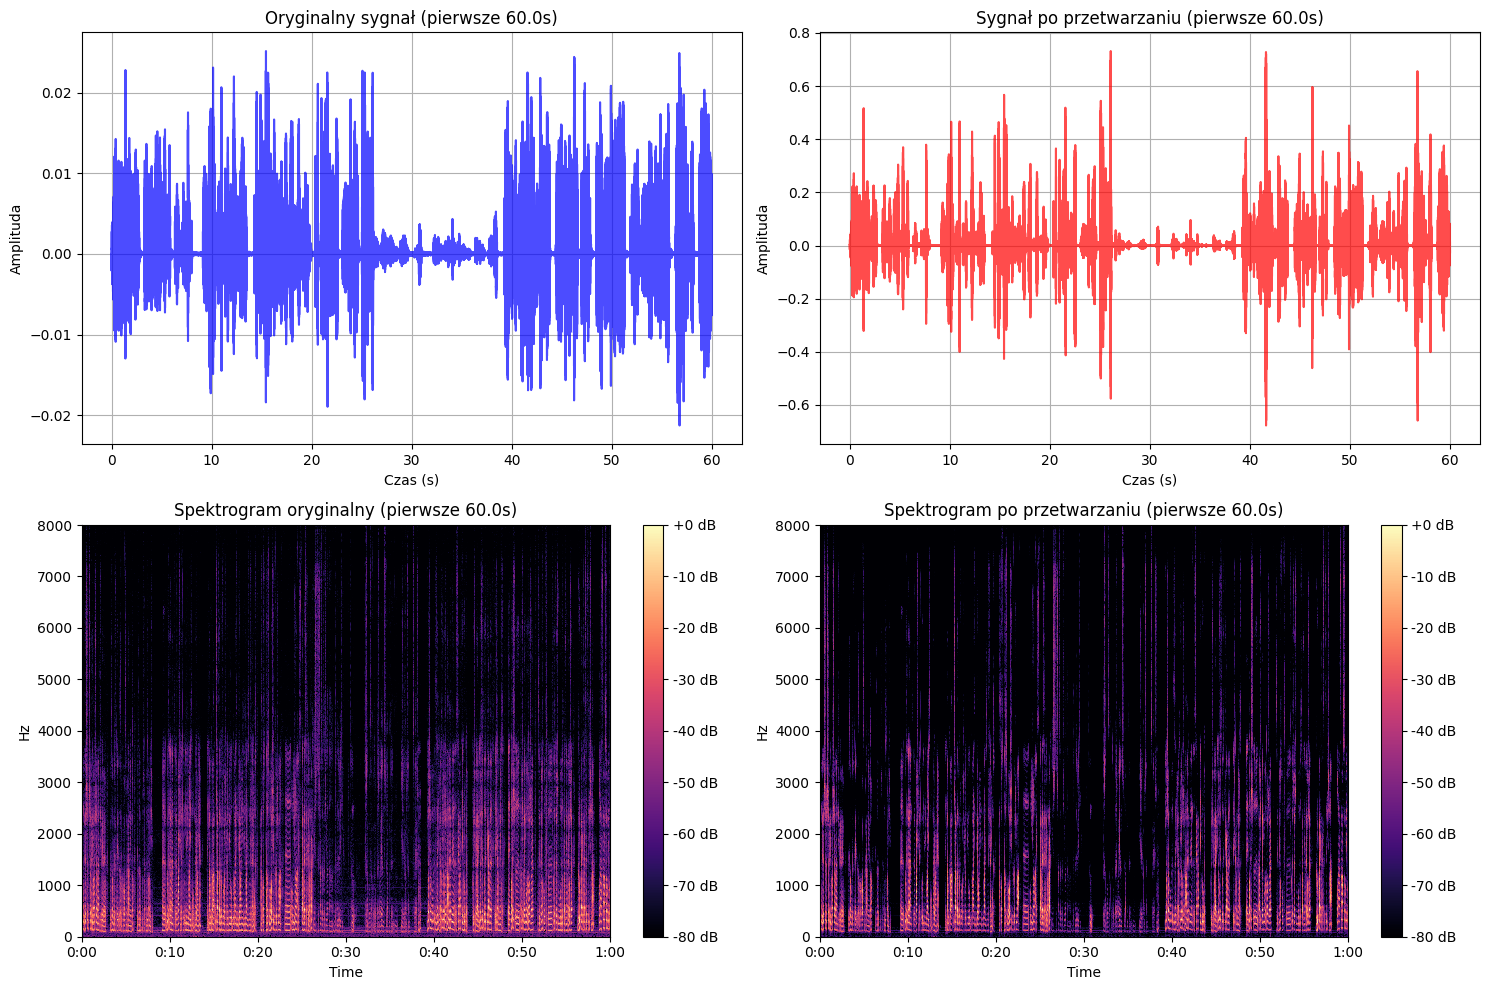

✅ Finalny poprawiony plik zapisany jako: final_enhanced_denoised_output_audio.wav

Teraz możesz odtworzyć 'final_enhanced_denoised_...' i sprawdzić różnicę!


In [101]:
if total_duration_seconds is not None:
    if 'audio' in locals() and audio is not None:
        print("\n=== KROK 4: WIZUALIZACJA I PRZETWARZANIE CAŁEGO PLIKU ===")

        global_noise_sample_for_full_file = None
        try:
            noise_start_idx = int(NOISE_START_TIMESTAMP_SECONDS * sr)
            noise_end_idx = int((NOISE_START_TIMESTAMP_SECONDS + NOISE_PROFILE_DURATION_SEC) * sr)

            if noise_end_idx > len(audio):
                print(f"❌ Ostrzeżenie: Żądany zakres próbki szumu ({NOISE_START_MIN}m {NOISE_START_SEC}s do {NOISE_PROFILE_DURATION_SEC}s dalej) wykracza poza długość pliku ({len(audio)/sr:.1f}s).")
                print("Biorę próbkę szumu od końca pliku lub krótszą.")
                noise_end_idx = len(audio)
                noise_start_idx = max(0, noise_end_idx - int(NOISE_PROFILE_DURATION_SEC * sr))
            
            global_noise_sample_for_full_file = audio[noise_start_idx:noise_end_idx]
            print(f"✅ Globalna próbka szumu ({len(global_noise_sample_for_full_file)/sr:.1f}s) pobrana z {NOISE_START_MIN}m {NOISE_START_SEC}s (z pełnego audio).")
        except Exception as e:
            print(f"❌ Błąd przy pobieraniu globalnej próbki szumu z pełnego audio: {e}")
            global_noise_sample_for_full_file = None

        current_prop_decrease = PROP_DECREASE
        if global_noise_sample_for_full_file is None or len(global_noise_sample_for_full_file) == 0:
            print("Nie udało się pobrać próbki szumu lub jest pusta. Redukcja szumu może być pominięta.")
            current_prop_decrease = 0.0

        # --- WYKRES HISTOGRAMU PRZED PRZETWARZANIEM ---
        plt.figure(figsize=(10, 5))
        plt.hist(audio, bins=100, alpha=0.7, color='blue', label='Oryginalne')
        plt.axvline(QUIET_THRESHOLD, color='red', linestyle='--', label='Quiet Threshold')
        plt.axvline(-QUIET_THRESHOLD, color='red', linestyle='--')
        plt.title('Rozkład Amplitud Oryginalnego Audio przed Wzmocnieniem')
        plt.xlabel('Amplituda')
        plt.ylabel('Częstość')
        plt.legend()
        plt.grid(True)
        plt.show()
        print(f"Rozkład amplitud: dźwięki poniżej |{QUIET_THRESHOLD:.2f}| zostaną wzmocnione.")


        # --- Przetwarzanie CAŁEGO pliku ---
        processed_audio_step4_full = np.copy(audio)

        for i in tqdm(range(len(processed_audio_step4_full)), desc="Wzmacnianie cichych fragmentów"):
            if np.abs(processed_audio_step4_full[i]) < QUIET_THRESHOLD:
                processed_audio_step4_full[i] *= GAIN_FACTOR
        
        print("✅ Ciche fragmenty wzmocnione.")

        # Krok 5a: Redukcja szumu (ZAWSZE używamy nr.reduce_noise)
        if current_prop_decrease > 0 and global_noise_sample_for_full_file is not None and len(global_noise_sample_for_full_file) > 0:
            print("Używam zaawansowanej redukcji szumu (może potrwać dłużej)...")
            # Pierwszy przebieg (agresywny dla szumu wiatraków)
            processed_audio_step5_full = nr.reduce_noise(y=processed_audio_step4_full, sr=sr, 
                                                            y_noise=global_noise_sample_for_full_file, prop_decrease=current_prop_decrease)
            
            # Opcjonalnie: Drugi przebieg z mniejszą redukcją, dla subtelniejszego szumu
            # processed_audio_step5_full = nr.reduce_noise(y=processed_audio_step5_full, sr=sr, 
            #                                               y_noise=global_noise_sample_for_full_file, prop_decrease=0.5) 
            print("✅ Szum tła usunięty.")
        else:
            processed_audio_step5_full = processed_audio_step4_full
            print("⚠️ Redukcja szumu pominięta (brak próbki szumu lub PROP_DECREASE = 0).")
        
        processed_audio_step5_full = librosa.util.normalize(processed_audio_step5_full)
        print("✅ Normalizacja do piku 1.0.")
        
        if FINAL_BOOST_DB > 0:
            boost_linear_gain = 10**(FINAL_BOOST_DB / 20)
            processed_audio_step5_full *= boost_linear_gain
            processed_audio_step5_full = librosa.util.normalize(processed_audio_step5_full)
            print(f"✅ Dodatkowe wzmocnienie o {FINAL_BOOST_DB}dB i ponowna normalizacja.")

        # --- WIZUALIZACJA PORÓWNANIA ---
        plot_duration_sec_local = min(total_duration_seconds, PLOT_DURATION_SEC) 
        plot_end_sample_idx = int(plot_duration_sec_local * sr)

        plot_orig_fragment = audio[:plot_end_sample_idx]
        plot_processed_fragment = processed_audio_step5_full[:plot_end_sample_idx]
        plot_time_axis = np.linspace(0, len(plot_orig_fragment)/sr, len(plot_orig_fragment))
        
        if total_duration_seconds > plot_duration_sec_local:
            print(f"⚠️ Uwaga: Plik audio jest dłuższy niż {plot_duration_sec_local:.1f}s. Wykresy pokazują tylko pierwsze {plot_duration_sec_local:.1f}s.")

        plt.figure(figsize=(15, 10))

        plt.subplot(2, 2, 1)
        plt.plot(plot_time_axis, plot_orig_fragment, alpha=0.7, color='blue')
        plt.title(f"Oryginalny sygnał (pierwsze {plot_duration_sec_local:.1f}s)")
        plt.xlabel("Czas (s)")
        plt.ylabel("Amplituda")
        plt.grid(True)

        plt.subplot(2, 2, 2)
        plt.plot(plot_time_axis, plot_processed_fragment, alpha=0.7, color='red')
        plt.title(f"Sygnał po przetwarzaniu (pierwsze {plot_duration_sec_local:.1f}s)")
        plt.xlabel("Czas (s)")
        plt.ylabel("Amplituda")
        plt.grid(True)

        stft_orig = librosa.stft(plot_orig_fragment)
        db_spectrogram_orig = librosa.amplitude_to_db(np.abs(stft_orig), ref=np.max)
        plt.subplot(2, 2, 3)
        librosa.display.specshow(db_spectrogram_orig, sr=sr, x_axis='time', y_axis='hz')
        plt.title(f"Spektrogram oryginalny (pierwsze {plot_duration_sec_local:.1f}s)")
        plt.colorbar(format='%+2.0f dB')

        stft_processed = librosa.stft(plot_processed_fragment)
        db_spectrogram_processed = librosa.amplitude_to_db(np.abs(stft_processed), ref=np.max)
        plt.subplot(2, 2, 4)
        librosa.display.specshow(db_spectrogram_processed, sr=sr, x_axis='time', y_axis='hz')
        plt.title(f"Spektrogram po przetwarzaniu (pierwsze {plot_duration_sec_local:.1f}s)")
        plt.colorbar(format='%+2.0f dB')

        plt.tight_layout()
        plt.show()

        output_filename = f"final_enhanced_denoised_{os.path.basename(audio_file_path)}"
        sf.write(output_filename, processed_audio_step5_full, sr)
        print(f"✅ Finalny poprawiony plik zapisany jako: {output_filename}")
        print("\nTeraz możesz odtworzyć 'final_enhanced_denoised_...' i sprawdzić różnicę!")


    elif 'audio' not in locals() or audio is None and total_duration_seconds is not None:
        print("\n=== KROK 4: PRZETWARZANIE CAŁEGO PLIKU W KAWAŁKACH ===")

        CHUNK_DURATION_SECONDS = 10 
        output_temp_dir = "temp_processed_chunks"
        os.makedirs(output_temp_dir, exist_ok=True)
        
        processed_chunk_files = []

        num_chunks = int(np.ceil(total_duration_seconds / CHUNK_DURATION_SECONDS))

        print(f"Plik będzie przetwarzany w {num_chunks} kawałkach po {CHUNK_DURATION_SECONDS}s.")

        global_noise_sample_for_chunks = None
        if 'global_noise_sample' in locals():
            global_noise_sample_for_chunks = global_noise_sample
        else:
            print("❌ Błąd: 'global_noise_sample' nie została zdefiniowana w Kroku 3. Redukcja szumu może nie działać.")

        for i in tqdm(range(num_chunks), desc="Przetwarzanie chunków"):
            start_time = i * CHUNK_DURATION_SECONDS
            end_time = min((i + 1) * CHUNK_DURATION_SECONDS, total_duration_seconds)
            duration = end_time - start_time
            
            if duration <= 0:
                continue

            try:
                chunk_raw, _ = librosa.load(audio_file_path, sr=TARGET_SR, 
                                            offset=start_time, duration=duration)
                
                processed_chunk = process_audio_chunk(chunk_raw, TARGET_SR, global_noise_sample_for_chunks)
                
                chunk_output_path = os.path.join(output_temp_dir, f"chunk_{i:04d}.wav")
                sf.write(chunk_output_path, processed_chunk, TARGET_SR)
                processed_chunk_files.append(chunk_output_path)

            except Exception as e:
                print(f"❌ Błąd podczas przetwarzania chunka {i} (od {start_time:.1f}s do {end_time:.1f}s): {e}")
                
        print(f"✅ Przetwarzanie chunków zakończone. Zapisano {len(processed_chunk_files)} tymczasowych plików.")

    else:
        print("\n❌ Brak danych audio. Upewnij się, że Krok 2 zakończył się sukcesem.")

else:
    print("\n❌ Brak długości pliku. Upewnij się, że Krok 2 zakończył się sukcesem.")


In [102]:
if 'processed_chunk_files' in locals() and processed_chunk_files:
    print("\n=== KROK 5: ŁĄCZENIE PRZETWORZONYCH KAWAŁKÓW ===")
    
    combined_audio = AudioSegment.empty()

    for chunk_file in tqdm(processed_chunk_files, desc="Łączenie chunków"):
        try:
            chunk_audio_segment = AudioSegment.from_wav(chunk_file)
            combined_audio += chunk_audio_segment
        except Exception as e:
            print(f"❌ Błąd podczas łączenia pliku {chunk_file}: {e}")

    final_output_filename = f"final_enhanced_denoised_{os.path.basename(audio_file_path)}"
    combined_audio.export(final_output_filename, format="wav")
    
    print(f"✅ Finalny poprawiony plik zapisany jako: {final_output_filename}")
    print(f"\nTeraz możesz odtworzyć '{final_output_filename}' i sprawdzić różnicę!")

    print(f"\nUsuwam tymczasowe pliki z folderu '{output_temp_dir}'...")
    for f in os.listdir(output_temp_dir):
        os.remove(os.path.join(output_temp_dir, f))
    os.rmdir(output_temp_dir)
    print("✅ Tymczasowe pliki usunięte.")
elif 'audio' in locals() and audio is not None:
    print("\nKrok 5 (Łączenie chunków) pominięty, ponieważ cały plik audio został przetworzony bezpośrednio w Kroku 4.")
else:
    print("\nBrak przetworzonych plików do połączenia. Upewnij się, że przetwarzanie zakończyło się sukcesem.")


Krok 5 (Łączenie chunków) pominięty, ponieważ cały plik audio został przetworzony bezpośrednio w Kroku 4.


In [103]:
# TYLKO TERAZ instalujemy i importujemy Whisper


import torch
from transformers import pipeline

# Parametry Whisper
WHISPER_MODEL_SIZE = "base" 
WHISPER_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\n=== KROK 6: TRANSKRYPCJA WHISPER Z TIMESTAMPAMI ===")

# Upewniamy się, że pliki do transkrypcji istnieją
final_enhanced_file_path = f"final_enhanced_denoised_{os.path.basename(audio_file_path)}"


if not os.path.exists(original_wav_file_path):
    print(f"❌ Błąd: Oryginalny plik WAV '{original_wav_file_path}' nie istnieje. Nie można go transkrybować.")
elif not os.path.exists(final_enhanced_file_path):
    print(f"❌ Błąd: Przetworzony plik WAV '{final_enhanced_file_path}' nie istnieje. Upewnij się, że Krok 4/5 zakończył się sukcesem.")
elif 'total_duration_seconds' not in locals() or total_duration_seconds is None:
    print("❌ Brak długości pliku (total_duration_seconds nie zostało poprawnie zdefiniowane w Kroku 2). Nie można przeprowadzić transkrypcji Whisper.")
else: 
    print(f"Ładowanie modelu Whisper: {WHISPER_MODEL_SIZE} na urządzeniu {WHISPER_DEVICE} (może potrwać przy pierwszym uruchomieniu)...")
    
    try:
        whisper_pipeline = pipeline(
            "automatic-speech-recognition", 
            model=f"openai/whisper-{WHISPER_MODEL_SIZE}", 
            chunk_length_s=30, 
            device=WHISPER_DEVICE,
            return_timestamps="word" 
        )
        print("✅ Model Whisper załadowany.")
        print("\n--- Pasek postępu dla Whisper ---")
        print("Transkrypcja długich plików jest przetwarzana w kawałkach. Transformers Pipeline domyślnie pokazuje postęp w konsoli (np. '1/X chunks processed').")

    except Exception as e:
        print(f"❌ Błąd przy ładowaniu modelu Whisper: {e}")
        print("Upewnij się, że masz zainstalowane 'transformers' i 'torch' (z CUDA, jeśli chcesz GPU).")
        print("Spróbuj też zmienić WHISPER_MODEL_SIZE na 'tiny' lub 'base' jeśli brakuje pamięci.")
        whisper_pipeline = None

    if whisper_pipeline:
        def transcribe_audio_and_save(file_path, model_pipeline, file_description):
            print(f"\n--- Transkrypcja: {file_description} ({os.path.basename(file_path)}) ---")
            
            base_filename = os.path.splitext(os.path.basename(file_path))[0]
            transcript_text_path = f"{base_filename}_transcript.txt"
            transcript_segments_path = f"{base_filename}_segments.txt"

            try:
                print(f"Rozpoczynam transkrypcję pliku: {file_path}")
                result = model_pipeline(file_path, return_timestamps="word")
                print(f"Zakończono transkrypcję pliku: {file_path}")
                
                if result is None or "text" not in result:
                    print(f"❌ Transkrypcja zwróciła pusty lub niepoprawny wynik dla '{file_path}'.")
                    return None

                print("✅ Transkrypcja zakończona.")
                
                with open(transcript_text_path, "w", encoding="utf-8") as f:
                    f.write(result["text"])
                print(f"✅ Pełny tekst transkrypcji zapisany do: {transcript_text_path}")

                with open(transcript_segments_path, "w", encoding="utf-8") as f:
                    f.write("=== SEGMENTY Z TIMESTAMPAMI ===\n")
                    if "chunks" in result:
                        for segment in result["chunks"]:
                            start_time = segment["timestamp"][0]
                            end_time = segment["timestamp"][1]
                            text = segment["text"]
                            f.write(f"[{start_time:.2f}s - {end_time:.2f}s] {text}\n")
                        print(f"✅ Segmenty transkrypcji z timestampami zapisane do: {transcript_segments_path}")
                    else:
                        print(f"⚠️ Brak segmentów 'chunks' w wyniku transkrypcji dla '{file_path}'. Nie zapisuję segmentów.")

                print("\n=== TEKST TRANSKRYPCJI (na ekranie) ===")
                print(result["text"])
                
                print("\n=== SEGMENTY Z TIMESTAMPAMI (na ekranie) ===")
                if "chunks" in result:
                    for segment in result["chunks"]:
                        start_time = segment["timestamp"][0]
                        end_time = segment["timestamp"][1]
                        text = segment["text"]
                        print(f"[{start_time:.2f}s - {end_time:.2f}s] {text}")
                else:
                    print("Brak segmentów 'chunks' w wyniku transkrypcji.")
                
                return result
            except Exception as e:
                print(f"❌ Błąd podczas transkrypcji pliku '{file_path}': {e}")
                import traceback
                traceback.print_exc() # Wydrukuj pełny traceback
                print("Może to być spowodowane formatem pliku, problemami z modelem Whisper, lub zbyt długim plikiem bez chunkowania przez Whisper.")
                return None

        original_transcript_result = transcribe_audio_and_save(original_wav_file_path, whisper_pipeline, "ORYGINALNY") 
        enhanced_transcript_result = transcribe_audio_and_save(final_enhanced_file_path, whisper_pipeline, "PRZETWORZONY") 

        print("\n=== PORÓWNANIE TRANSKRYPCJI ===")
        if original_transcript_result and enhanced_transcript_result:
            print("\nORYGINALNY:")
            print(original_transcript_result["text"])
            print("\nPRZETWORZONY:")
            print(enhanced_transcript_result["text"])
            
            print("\nAnalizuj różnice w tekście i timestampach, aby ocenić poprawę jakości.")
        else:
            print("Nie udało się uzyskać obu transkrypcji do porównania.")
    else:
        print("Model Whisper nie został poprawnie załadowany. Nie mogę przeprowadzić transkrypcji.")



=== KROK 6: TRANSKRYPCJA WHISPER Z TIMESTAMPAMI ===
Ładowanie modelu Whisper: base na urządzeniu cuda (może potrwać przy pierwszym uruchomieniu)...


Device set to use cuda
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


✅ Model Whisper załadowany.

--- Pasek postępu dla Whisper ---
Transkrypcja długich plików jest przetwarzana w kawałkach. Transformers Pipeline domyślnie pokazuje postęp w konsoli (np. '1/X chunks processed').

--- Transkrypcja: ORYGINALNY (output_audio.wav) ---
Rozpoczynam transkrypcję pliku: C:\Users\G\Documents\AlchemistOne\lowquality\output_audio.wav
Zakończono transkrypcję pliku: C:\Users\G\Documents\AlchemistOne\lowquality\output_audio.wav
✅ Transkrypcja zakończona.
✅ Pełny tekst transkrypcji zapisany do: output_audio_transcript.txt
✅ Segmenty transkrypcji z timestampami zapisane do: output_audio_segments.txt

=== TEKST TRANSKRYPCJI (na ekranie) ===
 Mówię, te trzy takie dwa, trzy elementy się pojawiają. Wiesz, nową się już tutaj zablokowało z tym ekranu, nie wiem co. Więc będę po prostu tak mówił z pamięci. Był ten element właśnie takiego indywidualizmu, ma działanie. I tam by chyba uszwarca wychodziło właśnie jako indywidualizm wydziałaniu, indywidualizm w myśleniu. A z osobowo

In [104]:
if 'original_transcript_result' in locals() and original_transcript_result is not None and \
   'enhanced_transcript_result' in locals() and enhanced_transcript_result is not None:
    
    print(f"\n=== KROK 7: OBLICZANIE WORD ERROR RATE (WER) ===")

    # W idealnym scenariuszu, do obliczenia WER potrzebujemy:
    # 1. `reference`: Poprawnej, ręcznie transkrybowanej wersji audio.
    # 2. `hypothesis`: Transkrypcji wygenerowanej przez system (Whisper).
    
    # Ponieważ nie mamy referencyjnej transkrypcji, użyjemy transkrypcji ORYGINALNEGO PLIKU jako 'referencji',
    # a transkrypcji PRZETWORZONEGO PLIKU jako 'hipotezy'.
    # Należy pamiętać, że to nie jest prawdziwe WER w sensie oceny jakości systemu ASR.
    # To raczej mierzy, jak bardzo transkrypcja "zmieniła się" po naszym przetwarzaniu audio.
    # Niższy WER w tym przypadku oznaczałby, że przetworzone audio dało transkrypcję bliższą oryginalnej.
    # Jeśli naszym celem jest poprawa jakości, spodziewamy się, że WER między 'referencją' (oryginalna transkrypcja)
    # a 'hipotezą' (ulepszona transkrypcja) będzie mniejsze, jeśli ulepszona transkrypcja jest "bliżej prawdy",
    # ale bez prawdziwej referencji to jest trudne do oceny.
    
    reference_text = original_transcript_result["text"]
    hypothesis_text = enhanced_transcript_result["text"]

    # WER liczy błędy na poziomie słów. Domyślnie JiWER tokenizuje tekst.
    error = wer(reference_text, hypothesis_text)

    print(f"\n--- WER (Oryginalna transkrypcja vs Przetworzona transkrypcja) ---")
    print(f"Oryginalny tekst: \n{reference_text}\n")
    print(f"Przetworzony tekst: \n{hypothesis_text}\n")
    print(f"Word Error Rate (WER): {error:.4f}")

    print("\n=== INTERPRETACJA WER ===")
    print("• WER bliskie 0 oznacza, że transkrypcje są bardzo podobne.")
    print("• WER większe od 0 wskazuje na różnice w słowach (insercje, delecje, substytucje).")
    print("• W tym kontekście (bez referencyjnej transkrypcji):")
    print("  - Jeśli transkrypcja PRZETWORZONEGO PLIKU jest subiektywnie lepsza,")
    print("    a WER jest wysokie, oznacza to, że Whisper zmienił wiele słów na lepsze.")
    print("  - Jeśli WER jest niskie, a jakość subiektywnie się poprawiła,")
    print("    oznacza to, że Whisper w obu przypadkach radził sobie podobnie,")
    print("    lub zmiany były subtelne.")
    print("Najlepiej jest ręcznie porównać transkrypcje i ocenić, czy zmiany są na lepsze!")

else:
    print("❌ Nie można obliczyć WER. Upewnij się, że transkrypcje w Kroku 6 zostały pomyślnie wygenerowane.")



=== KROK 7: OBLICZANIE WORD ERROR RATE (WER) ===

--- WER (Oryginalna transkrypcja vs Przetworzona transkrypcja) ---
Oryginalny tekst: 
 Mówię, te trzy takie dwa, trzy elementy się pojawiają. Wiesz, nową się już tutaj zablokowało z tym ekranu, nie wiem co. Więc będę po prostu tak mówił z pamięci. Był ten element właśnie takiego indywidualizmu, ma działanie. I tam by chyba uszwarca wychodziło właśnie jako indywidualizm wydziałaniu, indywidualizm w myśleniu. A z osobowości wychodziła obniżona extraversja, chyba tak. I jeszcze zresztą szwarsa wychodziła ta dependability. To też tam było wysoko, bo też o 1 czy 2 punkty nierzej tylko niż ten serdej rekszty. I to trzeba by byłoby zdefiniować, ale chodzi o to, że mamy pewien schemat w tej grupy, który się pojawiaia i to już jest dosyć ciekawy wniosek. To też tam się pojawiło to, że z tych wniosków, tylko też to jeszcze byłoby do sprawdzenia tego, że grupa jako taka specyficzna, ona sama w sobie przejawia tendencje, co w sumie wyobrażało z te

In [105]:
if 'original_transcript_result' in locals() and original_transcript_result is not None and \
   'enhanced_transcript_result' in locals() and enhanced_transcript_result is not None:
    
    print(f"\n=== KROK 8: DIARYZACJA MÓWCÓW I POŁĄCZENIE Z TRANSKRYPCJĄ ===")

    # --- KROK 8a: UZYSKAJ TOKEN AUTORYZACJI Z HUGGING FACE ---
    print("\n⚠️ WAŻNE: Wymagany token autoryzacji z Hugging Face dla pyannote.audio.")
    print("1. Odwiedź https://huggingface.co/settings/tokens")
    print("2. Utwórz nowy token z rolą 'read' (lub 'write', ale 'read' wystarczy).")
    print("3. Wklej token poniżej. Będzie on używany do pobrania modelu do diaryzacji.")
    
    # Zastąp 'hf_YOUR_HUGGING_FACE_TOKEN' swoim rzeczywistym tokenem!
    #token_hf = "hf_YOUR_HUGGING_FACE_TOKEN" 
    token_hf = os.environ.get("HF_TOKEN") # Lepsza praktyka: pobierz z zmiennej środowiskowej
    
    if token_hf is None or token_hf == "hf_YOUR_HUGGING_FACE_TOKEN" or token_hf == "":
        print("❌ Błąd: Token autoryzacji Hugging Face nie został podany.")
        print("Ustaw zmienną środowiskową HF_TOKEN LUB zmień linię 'token_hf = ...' w kodzie.")
        print("Bez tokena diaryzacja nie będzie działać. Pominę Krok 8.")
        token_hf_available = False
    else:
        print("✅ Token Hugging Face dostępny.")
        token_hf_available = True
    
    if token_hf_available:
        # --- KROK 8b: Ładowanie modelu do diaryzacji pyannote.audio ---
        print(f"\nŁadowanie modelu do diaryzacji (może potrwać przy pierwszym uruchomieniu)...")
        try:
            # Używamy modelu 'pyannote/speaker-diarization-3.1'
            diarization_pipeline = Pipeline.from_pretrained(
                "pyannote/speaker-diarization-3.1",
                use_auth_token=token_hf
            ).to(WHISPER_DEVICE) # Przenieś model na CPU/GPU zgodnie z konfiguracją Whisper
            print("✅ Model do diaryzacji załadowany.")
        except Exception as e:
            print(f"❌ Błąd przy ładowaniu modelu do diaryzacji: {e}")
            print("Upewnij się, że token Hugging Face jest poprawny i masz połączenie z internetem.")
            print("Sprawdź też, czy wersja pyannote.audio jest kompatybilna (np. 3.1.1).")
            diarization_pipeline = None

        if diarization_pipeline:
            def diarize_and_combine(audio_file, transcript_chunks, file_description):
                print(f"\n--- Diaryzacja i łączenie: {file_description} ({os.path.basename(audio_file)}) ---")
                try:
                    # Wykonaj diaryzację
                    diarization_result = diarization_pipeline(audio_file)
                    
                    # Wizualizacja (opcjonalnie, dla debugowania)
                    # from pyannote.audio.core.io import Audio
                    # from pyannote.audio.features.utils import get_audio
                    # audio_data = Audio().read(audio_file)
                    # diarization_result.plot() # To otwiera okno, może być problematyczne w notebooku

                    # Przetwórz wyniki diaryzacji na bardziej czytelny format
                    speaker_segments = []
                    for segment, track, label in diarization_result.itertracks(yield_label=True):
                        speaker_segments.append({
                            "start": segment.start,
                            "end": segment.end,
                            "speaker": label
                        })
                    
                    # Połącz transkrypcję z informacją o mówcy
                    combined_transcript = []
                    current_speaker = "N/A" # Domyślny mówca
                    
                    for chunk in transcript_chunks:
                        word_start = chunk["timestamp"][0]
                        word_end = chunk["timestamp"][1]
                        word_text = chunk["text"].strip()
                        
                        # Znajdź mówcę dla danego słowa
                        for speaker_segment in speaker_segments:
                            # Jeśli segment mówcy obejmuje początek słowa, przypisz mówcę
                            if word_start >= speaker_segment["start"] and word_start < speaker_segment["end"]:
                                current_speaker = speaker_segment["speaker"]
                                break
                            # Jeśli słowo zaczyna się przed segmentem mówcy, a segment mówcy zaczyna się przed końcem słowa
                            # i segment jest bardzo krótki, to też możemy przypisać mówcę
                            elif word_start < speaker_segment["start"] and word_end > speaker_segment["start"] and \
                                (speaker_segment["end"] - speaker_segment["start"]) < 1.0: # Krótkie segmenty mówcy
                                current_speaker = speaker_segment["speaker"]
                                break

                        # Dodaj słowo z informacją o mówcy
                        combined_transcript.append(f"[{word_start:.2f}s - {word_end:.2f}s] {current_speaker}: {word_text}")
                    
                    # Wyświetl i zapisz połączoną transkrypcję
                    combined_transcript_path = f"{os.path.splitext(os.path.basename(audio_file))[0]}_diarized_transcript.txt"
                    with open(combined_transcript_path, "w", encoding="utf-8") as f:
                        for line in combined_transcript:
                            f.write(line + "\n")
                    print(f"✅ Transkrypcja z diaryzacją zapisana do: {combined_transcript_path}")

                    print(f"\n=== Transkrypcja z diaryzacją (na ekranie) dla {file_description} ===")
                    for line in combined_transcript:
                        print(line)

                    return combined_transcript
                except Exception as e:
                    print(f"❌ Błąd podczas diaryzacji lub łączenia dla pliku '{audio_file}': {e}")
                    return None
            
            # Wykonaj diaryzację i połącz dla oryginalnego pliku
            diarized_original_transcript = diarize_and_combine(
                original_wav_file_path, 
                original_transcript_result["chunks"], 
                "ORYGINALNY"
            )

            # Wykonaj diaryzację i połącz dla przetworzonego pliku
            diarized_enhanced_transcript = diarize_and_combine(
                final_enhanced_file_path, 
                enhanced_transcript_result["chunks"], 
                "PRZETWORZONY"
            )

            print("\n=== PODSUMOWANIE DIARYZACJI ===")
            if diarized_original_transcript and diarized_enhanced_transcript:
                print("Porównaj transkrypcje z informacją o mówcach, aby ocenić, czy diaryzacja działa poprawnie i czy przetwarzanie audio wpłynęło na jej jakość.")
            else:
                print("Diaryzacja nie powiodła się dla jednego lub obu plików.")
        else:
            print("Model do diaryzacji nie został poprawnie załadowany. Pominę Krok 8.")
    else:
        print("Brak tokena Hugging Face. Pominę Krok 8.")

else:
    print("❌ Nie można wykonać diaryzacji. Upewnij się, że transkrypcje w Kroku 6 zostały pomyślnie wygenerowane.")



=== KROK 8: DIARYZACJA MÓWCÓW I POŁĄCZENIE Z TRANSKRYPCJĄ ===

⚠️ WAŻNE: Wymagany token autoryzacji z Hugging Face dla pyannote.audio.
1. Odwiedź https://huggingface.co/settings/tokens
2. Utwórz nowy token z rolą 'read' (lub 'write', ale 'read' wystarczy).
3. Wklej token poniżej. Będzie on używany do pobrania modelu do diaryzacji.
❌ Błąd: Token autoryzacji Hugging Face nie został podany.
Ustaw zmienną środowiskową HF_TOKEN LUB zmień linię 'token_hf = ...' w kodzie.
Bez tokena diaryzacja nie będzie działać. Pominę Krok 8.
Brak tokena Hugging Face. Pominę Krok 8.
